In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
df_atrac = pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt', sep=';', encoding='utf-8', low_memory=False)
df_tempos = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacao.txt', sep=';', encoding='utf-8', low_memory=False)
df_paralis = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacaoParalisacao.txt', sep=';', encoding='utf-8', low_memory=False)

print('---------------------------------------------------------------------------------------------------------------------------------')
num_linhas1 = len(df_atrac)
num_linhas2 = len(df_tempos)
num_linhas3 = len(df_paralis)

print(f"O arquivo contém {num_linhas1} linhas.")
print(f"O arquivo contém {num_linhas2} linhas.")
print(f"O arquivo contém {num_linhas3} linhas.")

print('---------------------------------------------------------------------------------------------------------------------------------')

print(df_atrac.columns)
print('---------------------------------------------------------------------------------------------------------------------------------')
print(df_tempos.columns)
print('---------------------------------------------------------------------------------------------------------------------------------')
print(df_paralis.columns)


---------------------------------------------------------------------------------------------------------------------------------
O arquivo contém 78232 linhas.
O arquivo contém 78232 linhas.
O arquivo contém 91598 linhas.
---------------------------------------------------------------------------------------------------------------------------------
Index(['IDAtracacao', 'CDTUP', 'IDBerco', 'Berço', 'Porto Atracação',
       'Coordenadas', 'Apelido Instalação Portuária', 'Complexo Portuário',
       'Tipo da Autoridade Portuária', 'Data Atracação', 'Data Chegada',
       'Data Desatracação', 'Data Início Operação', 'Data Término Operação',
       'Ano', 'Mes', 'Tipo de Operação', 'Tipo de Navegação da Atracação',
       'Nacionalidade do Armador', 'FlagMCOperacaoAtracacao', 'Terminal',
       'Município', 'UF', 'SGUF', 'Região Geográfica', 'Região Hidrográfica',
       'Instalação Portuária em Rio', 'Nº da Capitania', 'Nº do IMO'],
      dtype='object')
-------------------------------

In [72]:
colunas = ['IDAtracacao', 'Porto Atracação', 'Data Atracação', 'Data Chegada', 'Data Desatracação',
           'Data Início Operação', 'Data Término Operação', 'Ano', 'Mes', 'Tipo de Operação',
           'Município', 'UF', 'Região Geográfica', 'Região Hidrográfica','Tipo da Autoridade Portuária']

df_atrac = pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt',
                            delimiter=';',
                            encoding='utf-8',
                            usecols=colunas,
                            low_memory=False)

df_atrac.head(10)

,IDAtracacao,Porto Atracação,Tipo da Autoridade Portuária,Data Atracação,Data Chegada,Data Desatracação,Data Início Operação,Data Término Operação,Ano,Mes,Tipo de Operação,Município,UF,Região Geográfica,Região Hidrográfica
0,3173,NaN,Porto Organizado,NaN,NaN,01/11/2020 00:00:00,NaN,NaN,2020,nov,NaN,NaN,NaN,NaN,NaN
1,3166,NaN,Porto Organizado,NaN,NaN,01/11/2020 00:00:00,NaN,NaN,2020,nov,NaN,NaN,NaN,NaN,NaN
2,3167,NaN,Porto Organizado,NaN,NaN,01/11/2020 00:00:00,NaN,NaN,2020,nov,NaN,NaN,NaN,NaN,NaN
3,3165,NaN,Porto Organizado,NaN,NaN,01/11/2020 00:00:00,NaN,NaN,2020,nov,NaN,NaN,NaN,NaN,NaN
4,3168,NaN,Porto Organizado,NaN,NaN,01/11/2020 00:00:00,NaN,NaN,2020,nov,NaN,NaN,NaN,NaN,NaN
5,2988,NaN,Porto Organizado,NaN,NaN,01/05/2020 00:00:00,NaN,NaN,2020,mai,NaN,NaN,NaN,NaN,NaN
6,2979,NaN,Porto Organizado,NaN,NaN,01/04/2020 00:00:00,NaN,NaN,2020,abr,NaN,NaN,NaN,NaN,NaN
7,2967,NaN,Porto Organizado,NaN,NaN,01/04/2020 00:00:00,NaN,NaN,2020,abr,NaN,NaN,NaN,NaN,NaN
8,2980,NaN,Porto Organizado,NaN,NaN,01/04/2020 00:00:00,NaN,NaN,2020,abr,NaN,NaN,NaN,NaN,NaN
9,3194,NaN,Porto Organizado,NaN,NaN,01/12/2020 00:00:00,NaN,NaN,2020,dez,NaN,NaN,NaN,NaN,NaN


In [ ]:
#NULL
df_atrac.isnull().sum()

,0
IDAtracacao,0
Porto Atracação,319
Tipo da Autoridade Portuária,0
Data Atracação,319
Data Chegada,319
Data Desatracação,0
Data Início Operação,3383
Data Término Operação,3384
Ano,0
Mes,0


/tmp/ipython-input-74-3276693730.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


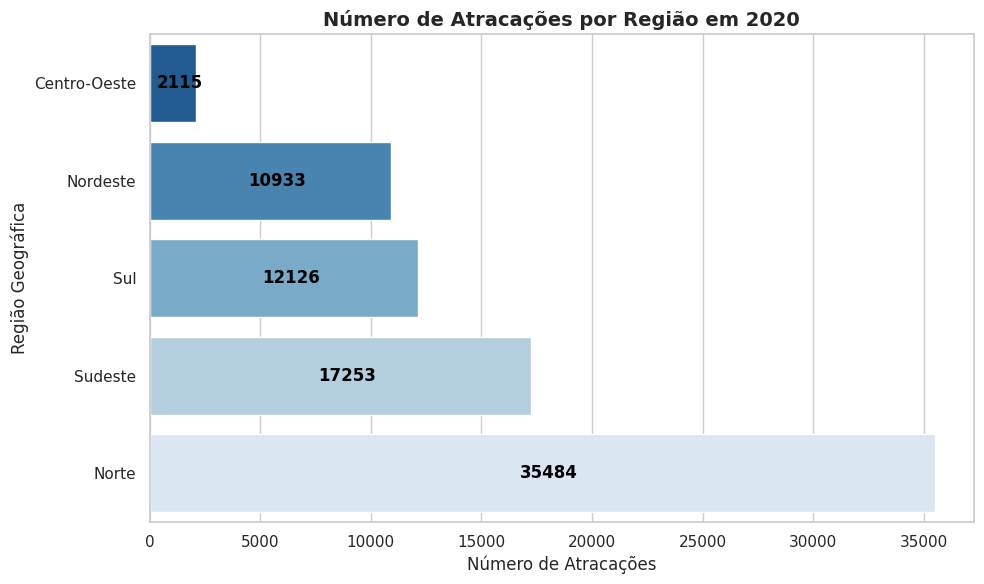

In [74]:
#QUAIS REGIÕES NO PAIS MAIS TIVERAM ATRACACOES NO ANO DE 2020?

sns.set_theme(style="whitegrid")
atracoes_por_regiao = df_atrac.groupby('Região Geográfica')['Data Atracação'].count().reset_index()
atracoes_por_regiao_sorted = atracoes_por_regiao.sort_values(by='Data Atracação', ascending=True)


plt.figure(figsize=(10, 6))
ax = sns.barplot(
    y=atracoes_por_regiao_sorted['Região Geográfica'],
    x=atracoes_por_regiao_sorted['Data Atracação'],
    palette="Blues_r"
)
for container in ax.containers:
    ax.bar_label(
        container, fmt='%d', fontsize=12, padding=5,
        color='black', weight='bold', label_type="center"
    )

plt.title('Número de Atracações por Região em 2020', fontsize=14, fontweight="bold")
plt.xlabel('Número de Atracações', fontsize=12)
plt.ylabel('Região Geográfica', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipython-input-75-2995828493.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


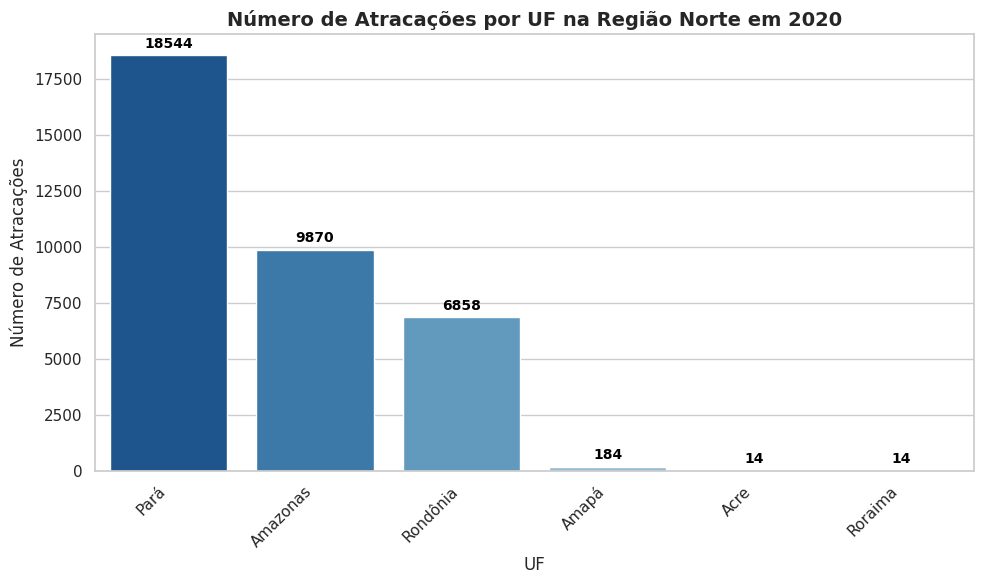

In [75]:
#NO NORTE DO PAIS QUAL FOI O ESTADO QUE MAIS TEVE ATRACACAO?


sns.set_theme(style="whitegrid")
df_norte_2020 = pd.read_csv(
    '/content/drive/MyDrive/2020/2020Atracacao.txt',delimiter=';',encoding='utf-8',index_col=0,low_memory=False)

df_norte_2020 = df_norte_2020[
    (df_norte_2020['Ano'] == 2020) &
    (df_norte_2020['Região Geográfica'] == 'Norte')
]

uf_atracacoes = df_norte_2020.groupby('UF')['Data Atracação'].count().reset_index()
uf_atracacoes_sorted = uf_atracacoes.sort_values(by='Data Atracação', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='UF',
    y='Data Atracação',
    data=uf_atracacoes_sorted,
    palette="Blues_r"
)
from matplotlib import font_manager
bold_font = font_manager.FontProperties(weight='bold')
for bar in ax.containers:
    ax.bar_label(
        bar,
        fmt='%d',
        label_type='edge',
        fontsize=10,
        padding=3,
        color="black",
        fontproperties=bold_font
    )
plt.title('Número de Atracações por UF na Região Norte em 2020', fontsize=14, fontweight="bold")
plt.xlabel('UF', fontsize=12)
plt.ylabel('Número de Atracações', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-76-1201114933.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


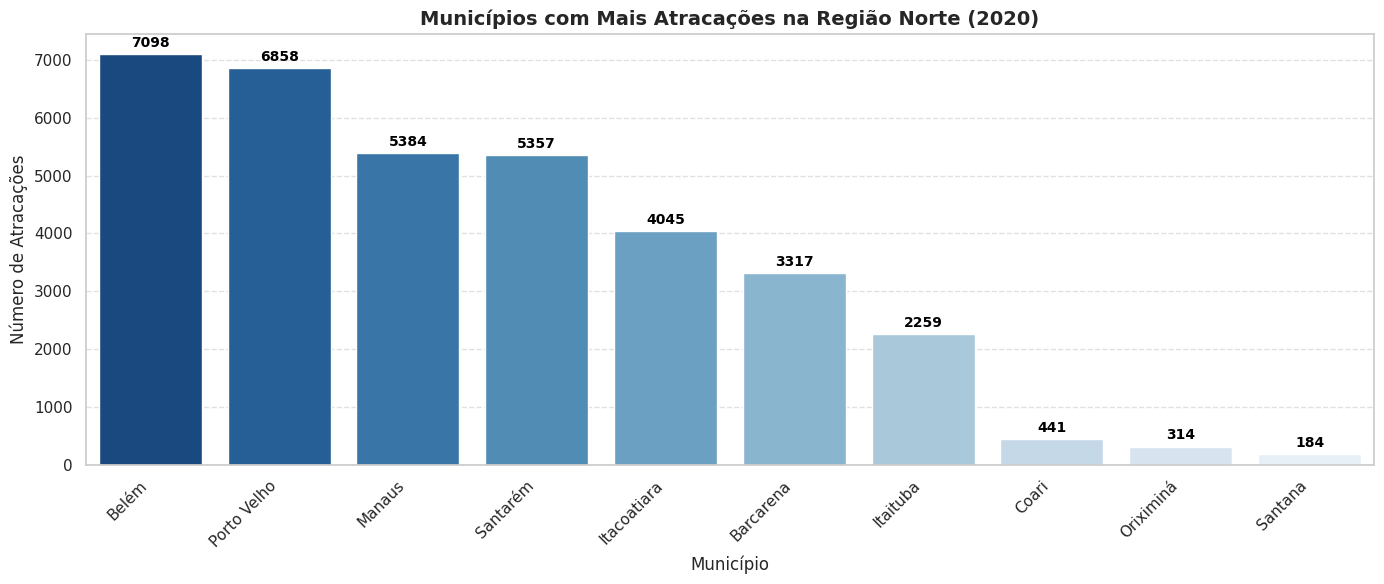

In [76]:

#NA REGIÃO NORTE ONDE HOUVE MAIS ATRACAÇÕES + RELACIONAR UF E MUNICIPIO:

sns.set_theme(style="whitegrid")
df_atrac = pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt',delimiter=';',encoding='utf-8',index_col=0,low_memory=False)

df_norte_2020 = df_atrac[
    (df_atrac['Ano'] == 2020) &
    (df_atrac['Região Geográfica'] == 'Norte')
]
municipios_p = df_norte_2020.groupby('Município')['Data Atracação'].count().reset_index()
municipios_p_sorted = municipios_p.sort_values(by='Data Atracação', ascending=False).head(10)
palette = sns.color_palette("Blues_r", len(municipios_p_sorted))
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    x='Município',
    y='Data Atracação',
    data=municipios_p_sorted,
    palette=palette
)
from matplotlib import font_manager
bold_font = font_manager.FontProperties(weight='bold')
for bar in ax.containers:
    ax.bar_label(
        bar,
        fmt='%d',
        label_type='edge',
        fontsize=10,
        padding=3,
        color="black",
        fontproperties=bold_font
    )
plt.xticks(rotation=45, ha='right')
plt.title('Municípios com Mais Atracações na Região Norte (2020)', fontsize=14, fontweight="bold")
plt.xlabel('Município', fontsize=12)
plt.ylabel('Número de Atracações', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [77]:

#QUAL É O COMPLEXO PORTUÁRIO NO PARÁ QUE MAIS RECEBEU ATRACAÇAO -> NOME

df_norte = df_norte_2020[df_norte_2020['UF'] == 'Pará']
porto_atrac = df_norte.groupby('Porto Atracação')['Data Atracação'].count().reset_index()
porto_atrac_sorted = porto_atrac.sort_values(by='Data Atracação', ascending=False)
print(porto_atrac_sorted)



                                Porto Atracação  Data Atracação
5                                         Belém            4843
15                                     Santarém            4629
22   Terminal Portuário Graneleiro de Barcarena            1319
18                 TUP J F de Oliveira de Belém            1311
7                                ETC Miritituba            1281
26                                Vila do Conde             985
21                   Terminal Ponta da Montanha             757
17                     TUP Bertolini - Santarém             728
8                   Estação Cianport Miritituba             652
16                        TUP Bertolini - Belém             480
10                                    Norte Log             429
24                           Terminal Trombetas             223
25                       Terminal Vila do Conde             220
20                   Terminal Fluvial de Juruti             130
9                Hidrovias do Brasil Mir

/tmp/ipython-input-78-3313280918.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


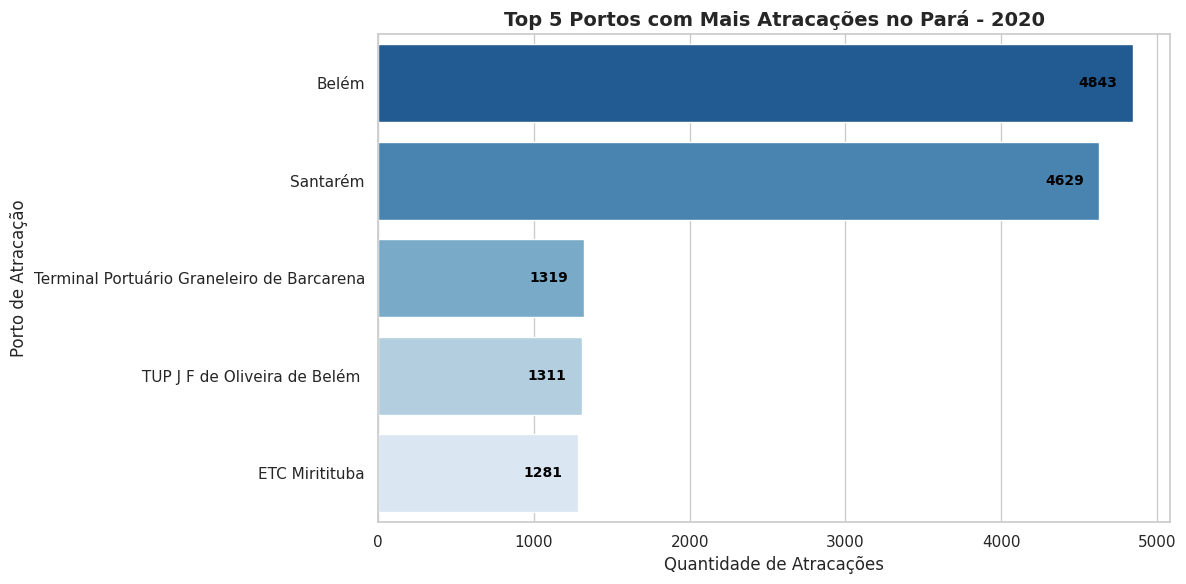

In [78]:

top_5_portos = pd.DataFrame({
    "Porto Atracação": [
        "Belém", "Santarém", "Terminal Portuário Graneleiro de Barcarena",
        " TUP J F de Oliveira de Belém ", "ETC Miritituba"
    ],
    "Data Atracação": [4843,4629,1319,1311,1281]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="Data Atracação",
    y="Porto Atracação",
    data=top_5_portos,
    palette="Blues_r"
)

from matplotlib import font_manager
bold_font = font_manager.FontProperties(weight='bold')
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width - 100,
        y,
        f'{int(width)}',
        ha='right',
        va='center',
        fontsize=10,
        color='black',
        fontproperties=bold_font
    )
plt.xlabel("Quantidade de Atracações", fontsize=12)
plt.ylabel("Porto de Atracação", fontsize=12)
plt.title("Top 5 Portos com Mais Atracações no Pará - 2020", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [79]:

# NO SUL QUAL FOI O ESTADO COM MAIS ATRACACOES

df_sul_2020 = df_atrac[(df_atrac['Ano'] == 2020) &
                                    (df_atrac['Região Geográfica'] == 'Sul')]
atracoes_por_uf = df_sul_2020.groupby('UF')['Data Atracação'].count().reset_index()
uf_mais_atracada = atracoes_por_uf.loc[atracoes_por_uf['Data Atracação'].idxmax()]
print(f"O estado com mais atracações na Região Sul em 2020 foi {uf_mais_atracada['UF']} "
      f"com {uf_mais_atracada['Data Atracação']} atracações.")

O estado com mais atracações na Região Sul em 2020 foi Rio Grande do Sul com 7306 atracações.


/tmp/ipython-input-80-3072729359.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


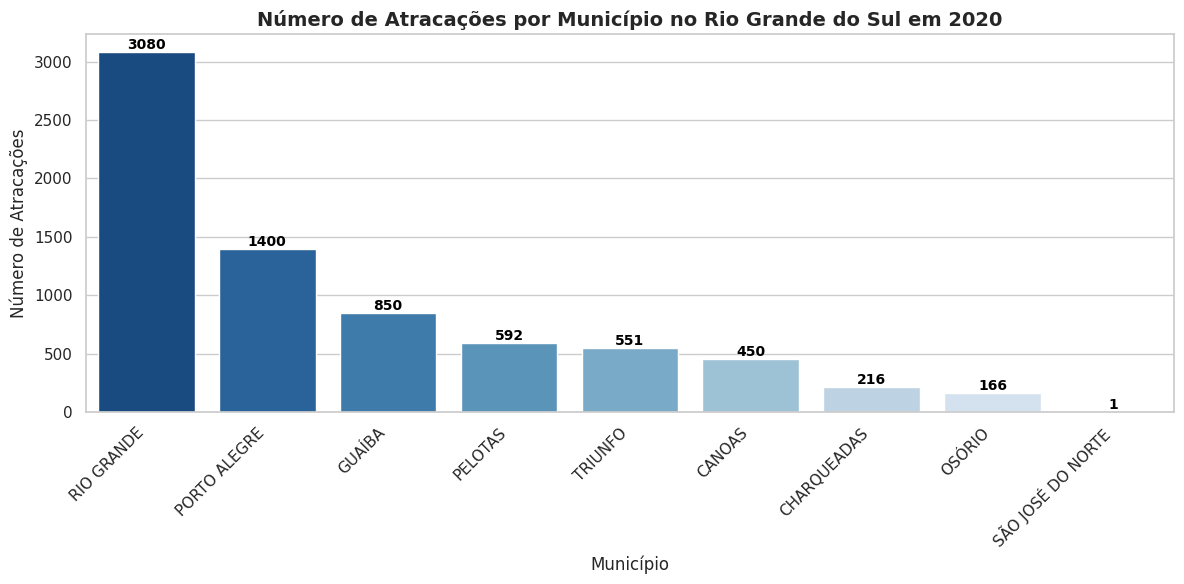

In [80]:
#DADOS ESPECÍFICOS DA REGIÃO - NO RS QUAL FOI O MUNICIPIO QUE MAIS RECEBEU ATRACACAO


df_rs = df_sul_2020[df_sul_2020['UF'] == 'Rio Grande do Sul'].copy()
df_rs['Município'] = df_rs['Município'].str.strip().str.upper()
municipios_rs = df_rs.groupby('Município')['Data Atracação'].count().reset_index()
municipios_rs_sorted = municipios_rs.sort_values(by='Data Atracação', ascending=False)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Município',
    y='Data Atracação',
    data=municipios_rs_sorted,
    palette="Blues_r"
)

from matplotlib import font_manager
bold_font = font_manager.FontProperties(weight='bold')
for bar in ax.patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    ax.text(
        x, height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        fontproperties=bold_font
    )

plt.title('Número de Atracações por Município no Rio Grande do Sul em 2020', fontsize=14, fontweight="bold")
plt.xlabel('Município', fontsize=12)
plt.ylabel('Número de Atracações', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [81]:
#QUAL É O TIPO DE OPERACAO MAIS COMUM NO SUL

print("----------------------------------------------------------------------------------------------------------------------------------------------------------")
df_atrac =  pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt', delimiter=';', encoding='utf-8', index_col=0, low_memory=False)
valores_unicos = sorted(df_atrac['Tipo de Operação'].dropna().astype(str).unique())
for i, valor in enumerate(valores_unicos, start=1):
    print(f"{i}. {valor}")

print("----------------------------------------------------------------------------------------------------------------------------------------------------------")
df_sul = df_atrac[df_atrac['Região Geográfica'] == 'Sul']
tipo_mais_comum = df_sul['Tipo de Operação'].value_counts()
print(tipo_mais_comum.head(1))




----------------------------------------------------------------------------------------------------------------------------------------------------------
1. Abastecimento
2. Apoio
3. Marinha
4. Misto
5. Movimentação da Carga
6. Passageiro
7. Reparo/Manutenção
----------------------------------------------------------------------------------------------------------------------------------------------------------
Tipo de Operação
Movimentação da Carga    10612
Name: count, dtype: int64


In [82]:
#EM PARANAGUÁ-PR - QUANTAS ATRACAÇÕES NO ANO DE 2020

file_path = "/content/drive/MyDrive/2020/2020Atracacao.txt"
df_parana = pd.read_csv(file_path, delimiter=";", encoding="utf-8", low_memory=False)
df_parana = df_parana[(df_parana['Ano'] == 2020) &
                                 (df_parana['Município'] == 'Paranaguá')]

num_atracacoes_paranagua = df_parana.shape[0]
print(f"O município de Paranaguá teve {num_atracacoes_paranagua} atracações em 2020.")

O município de Paranaguá teve 2418 atracações em 2020.


In [83]:

#QUAIS SAO OS TIPOS DE PARALISACOES EXISTENTES

caminho_arquivo = '/content/drive/MyDrive/2020/2020TemposAtracacaoParalisacao.txt'
df_paralis = pd.read_csv(caminho_arquivo, delimiter=';', encoding='utf-8', low_memory=False)
tipos_paralisacoes = sorted(df_paralis["DescricaoTempoDesconto"].dropna().unique())
print("Tipos únicos de paralisações:")
for tipo in tipos_paralisacoes:
    print("-", tipo)

Tipos únicos de paralisações:
- Acidente
- Aguardando carga
- Aguardando sequência de descarga
- Aguardando transporte rodoviário
- Arqueação
- Chuva e/ou outras condições climáticas desfavoráveis
- Falta de energia elétrica
- Fundeio sem previsão de atracação
- Greve ou falta de trabalhadores portuários avulsos
- Liberação de órgãos públicos
- Limpeza operacional
- Manobra de embarcação
- Manutenção preventiva
- Maré para embarcações com restrição de operação
- Motivo de segurança
- Mudança de porão
- Parada para almoço
- Peação da carga
- Pernoite de navio atracado
- Preparação de equipamentos do cais
- Problema operacional da embarcação
- Quebra de equipamento do Operador Portuário, devidamente comprovada
- Quebra de equipamento do Porto, devidamente comprovada
- Rechego
- Sem operação por conveniência do agente
- Sem operação por conveniência do armador
- Sem operação por conveniência do operador
- Troca de turno


In [84]:
#PARALISACAO PORTO DE PARANAGUÁ - CALCULAR AS HORAS PERDIDAS ENTRE O INICIO E TERMINO DA PARALISACAO - EU USO O ARQUIVO DF_PARALIS

df_atrac= pd.read_csv('/content/drive/MyDrive/2020/2020Atracacao.txt', delimiter=';', encoding='utf-8', low_memory=False)
df_tempos = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacao.txt', delimiter=';', encoding='utf-8', low_memory=False)
df_paraliS = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacaoParalisacao.txt', delimiter=';', encoding='utf-8', low_memory=False)

In [85]:
#HORAS PERDIDAS NAS PARALISACOES

df_paralis['DTInicio'] = pd.to_datetime(df_paralis['DTInicio'], dayfirst=True)
df_paralis['DTTermino'] = pd.to_datetime(df_paralis['DTTermino'], dayfirst=True)
df_paralis['Horas Perdidas'] = (df_paralis['DTTermino'] - df_paralis['DTInicio']).dt.total_seconds() / 3600

In [86]:
#DADOS SOMENTE DE PARANAGUÁ

df_atrac2020_paranagua = df_atrac[df_atrac['Porto Atracação'] == 'Paranaguá']
df_paralis_paranagua = df_paralis[df_paralis['IDAtracacao'].isin(df_atrac2020_paranagua['IDAtracacao'])]
df_merged = df_paralis_paranagua.merge(
    df_atrac2020_paranagua[['IDAtracacao', 'Data Atracação', 'Data Chegada', 'Data Desatracação', 'Data Início Operação', 'Data Término Operação']],
    on='IDAtracacao',
    how='left'
)
df_merged.head()

,IDTemposDescontos,IDAtracacao,DescricaoTempoDesconto,DTInicio,DTTermino,Horas Perdidas,Data Atracação,Data Chegada,Data Desatracação,Data Início Operação,Data Término Operação
0,541694,1058155,Maré para embarcações com restrição de operação,2020-01-22 01:01:00,2020-01-22 01:49:00,0.800000,20/01/2020 18:25:00,18/01/2020 10:00:00,22/01/2020 01:50:00,20/01/2020 22:00:00,21/01/2020 17:24:00
1,541770,1058440,Chuva e/ou outras condições climáticas desfavo...,2020-01-10 17:40:00,2020-01-10 18:00:00,0.333333,09/01/2020 07:05:00,08/01/2020 15:45:00,11/01/2020 03:00:00,09/01/2020 08:10:00,11/01/2020 00:45:00
2,541771,1058440,Mudança de porão,2020-01-10 15:20:00,2020-01-10 15:30:00,0.166667,09/01/2020 07:05:00,08/01/2020 15:45:00,11/01/2020 03:00:00,09/01/2020 08:10:00,11/01/2020 00:45:00
3,541772,1058440,Mudança de porão,2020-01-10 09:20:00,2020-01-10 09:35:00,0.250000,09/01/2020 07:05:00,08/01/2020 15:45:00,11/01/2020 03:00:00,09/01/2020 08:10:00,11/01/2020 00:45:00
4,541773,1058440,Mudança de porão,2020-01-10 04:15:00,2020-01-10 04:40:00,0.416667,09/01/2020 07:05:00,08/01/2020 15:45:00,11/01/2020 03:00:00,09/01/2020 08:10:00,11/01/2020 00:45:00


In [87]:
#JUNÇAO DOS DADOS - PARANAGUÁ

resumo = df_merged.groupby('IDAtracacao').agg({
    'Horas Perdidas': ['count', 'sum', 'mean'],
    'Data Término Operação': 'first'
}).reset_index()

resumo.columns = ['IDAtracacao', 'paralisacoes', 'total_paralisacao', 'media_paralisacao', 'tempo_otimo']
resumo.head()

,IDAtracacao,paralisacoes,total_paralisacao,media_paralisacao,tempo_otimo
0,1057660,33,29.383333,0.890404,11/01/2020 09:42:00
1,1057661,9,16.516667,1.835185,12/01/2020 23:47:00
2,1057666,58,69.633333,1.200575,03/01/2020 21:35:00
3,1057667,14,16.900000,1.207143,06/01/2020 21:35:00
4,1057668,139,156.933333,1.129017,28/01/2020 12:20:00


In [88]:
#QUANTAS VEZES CADA PARALISACAO OCORREU E HORAS TOTAIS

ocorrencias = df_paralis_paranagua.groupby('DescricaoTempoDesconto')['Horas Perdidas'].agg(['count', 'sum']).reset_index()
ocorrencias.columns = ['motivo', 'ocorrencias', 'horas_perdidas']
ocorrencias = ocorrencias.sort_values(by='horas_perdidas', ascending=False)
ocorrencias.head()

,motivo,ocorrencias,horas_perdidas
2,Chuva e/ou outras condições climáticas desfavo...,9713,22311.366667
8,Maré para embarcações com restrição de operação,4472,6797.150000
10,"Quebra de equipamento do Operador Portuário, d...",4061,4336.650000
9,Mudança de porão,17188,4191.566667
11,"Quebra de equipamento do Porto, devidamente co...",3238,3799.983333


In [89]:

#MOTIVO MAIS COMUM EM PARANAGUÁ

df_paranagua = df_paralis.merge(df_atrac[['IDAtracacao', 'Porto Atracação']],on='IDAtracacao',how='left')
df_paranagua = df_paranagua[df_paranagua['Porto Atracação'] == 'Paranaguá']

motivos = df_paranagua.groupby('DescricaoTempoDesconto')['Horas Perdidas'].sum().reset_index()
motivos_sorted = motivos.sort_values(by='Horas Perdidas', ascending=False)
motivo_mais_comum = motivos_sorted.iloc[0]
print("Motivo mais comum de paralisação em Paranaguá:")
print(motivo_mais_comum)

Motivo mais comum de paralisação em Paranaguá:
DescricaoTempoDesconto    Chuva e/ou outras condições climáticas desfavo...
Horas Perdidas                                                 22311.366667
Name: 2, dtype: object


/tmp/ipython-input-90-2952151541.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=ocorrencias_sorted,y='motivo',x='horas_perdidas',palette='Blues_d')


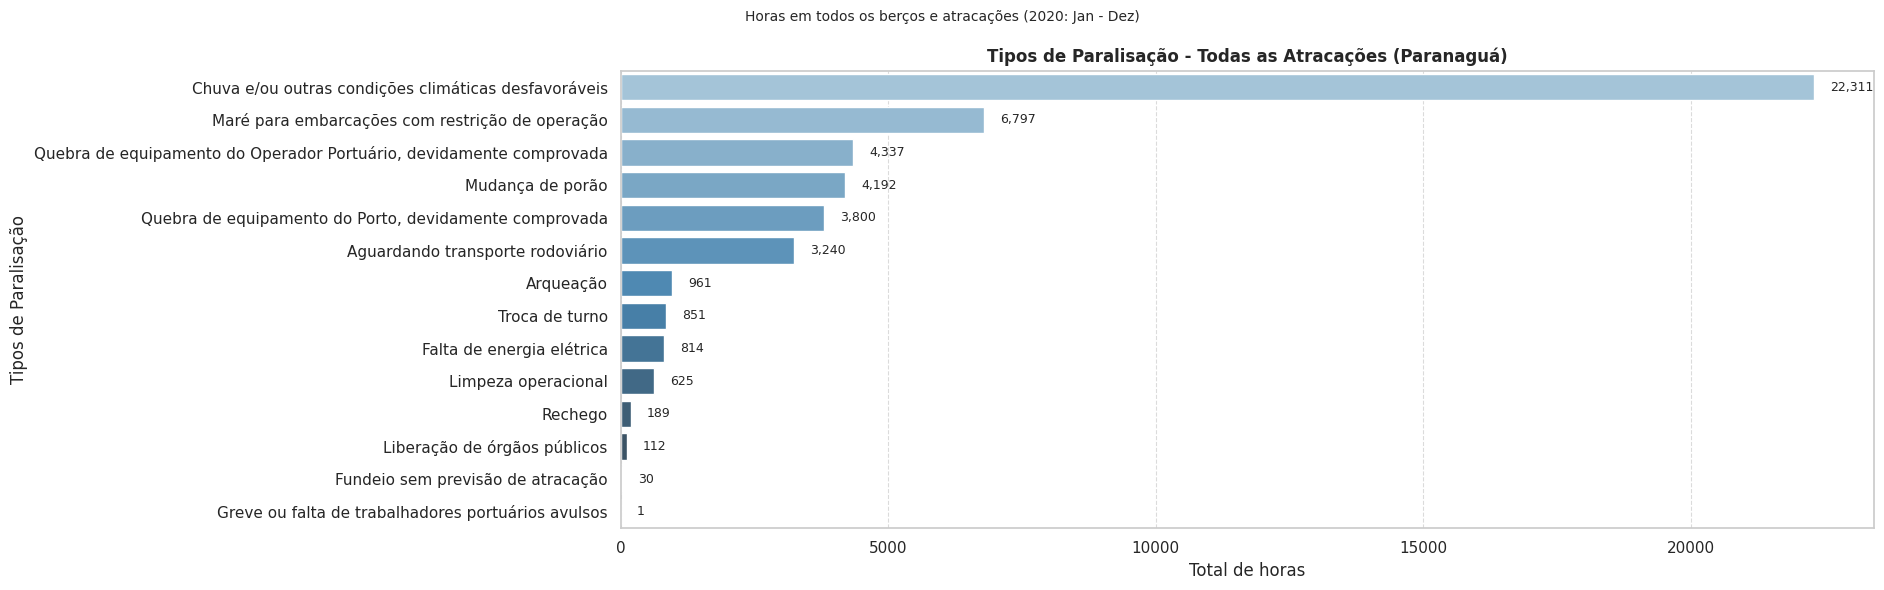

In [90]:
#OS PRINCIPAIS MOTIVOS DE PARALISACAO EM PARANAGUA E O VALOR DE HORAS OCORRIDO

sns.set(style="whitegrid")
ocorrencias_sorted = ocorrencias.sort_values('horas_perdidas', ascending=False)
plt.figure(figsize=(19, 6))
barplot = sns.barplot(data=ocorrencias_sorted,y='motivo',x='horas_perdidas',palette='Blues_d')
for bar in barplot.patches:
    width = bar.get_width()
    plt.text(width + 300, bar.get_y() + bar.get_height() / 2,f'{width:,.0f}',va='center',fontsize=9)
plt.title('Tipos de Paralisação - Todas as Atracações (Paranaguá)', fontsize=12, fontweight='bold')
plt.suptitle('Horas em todos os berços e atracações (2020: Jan - Dez)', fontsize=10)
plt.xlabel('Total de horas')
plt.ylabel('Tipos de Paralisação')
plt.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

  Região Geográfica                             DescricaoTempoDesconto  \
0          Nordeste  Chuva e/ou outras condições climáticas desfavo...   
1             Norte                  Fundeio sem previsão de atracação   
2           Sudeste                  Fundeio sem previsão de atracação   
3               Sul  Chuva e/ou outras condições climáticas desfavo...   

   Horas Perdidas  
0     4828.716667  
1    11837.100000  
2    33612.150000  
3    30734.216667  


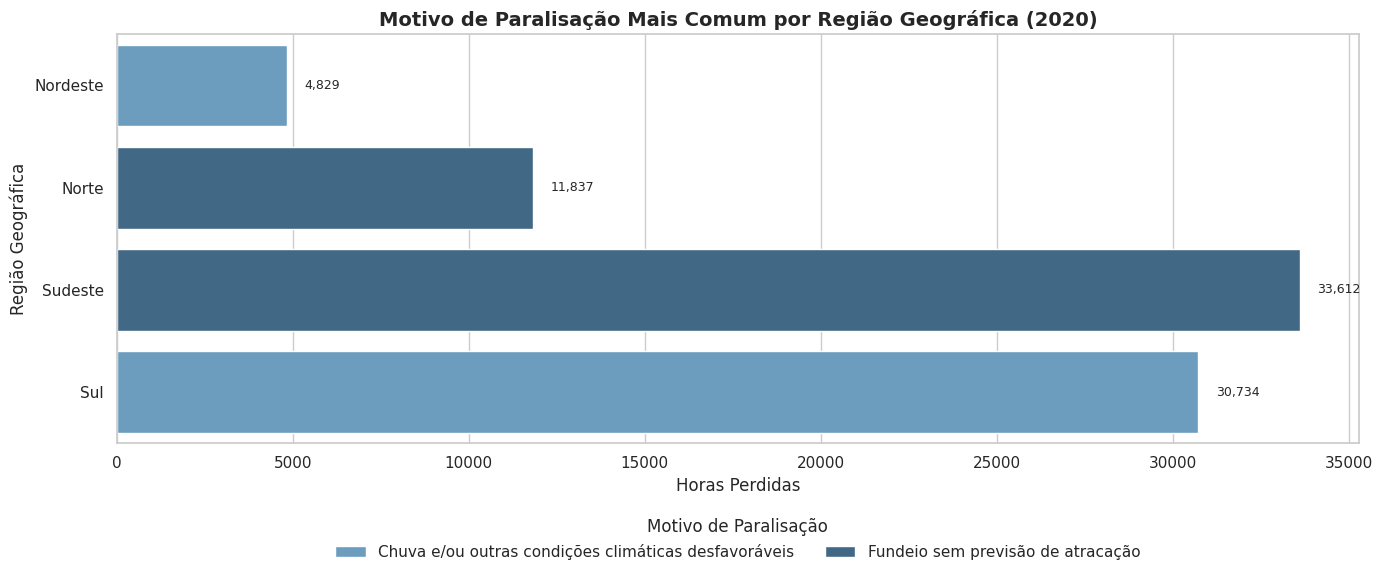

In [91]:
#PARALISACAO POR REGIÃO GEOGRAFICA - HORAS

df_paralisado = df_paralis.merge(df_atrac[['IDAtracacao', 'Região Geográfica']],on='IDAtracacao',how='left')
agrupado = df_paralisado.groupby(['Região Geográfica', 'DescricaoTempoDesconto'])['Horas Perdidas'].sum().reset_index()
top_por_regiao = agrupado.sort_values(['Região Geográfica', 'Horas Perdidas'],ascending=[True, False]).groupby('Região Geográfica').first().reset_index()
print(top_por_regiao)

plt.figure(figsize=(14, 6))
barplot = sns.barplot(
    data=top_por_regiao,x='Horas Perdidas',y='Região Geográfica', hue='DescricaoTempoDesconto',palette='Blues_d')
for bar in barplot.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if width > 0:
        plt.text(width + 500,y,f'{width:,.0f}',va='center',fontsize=9)
plt.title('Motivo de Paralisação Mais Comum por Região Geográfica (2020)', fontsize=14, weight='bold')
plt.xlabel('Horas Perdidas')
plt.ylabel('Região Geográfica')
plt.legend(
    title='Motivo de Paralisação',loc='upper center',bbox_to_anchor=(0.5, -0.15),ncol=2,frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipython-input-92-3399684476.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


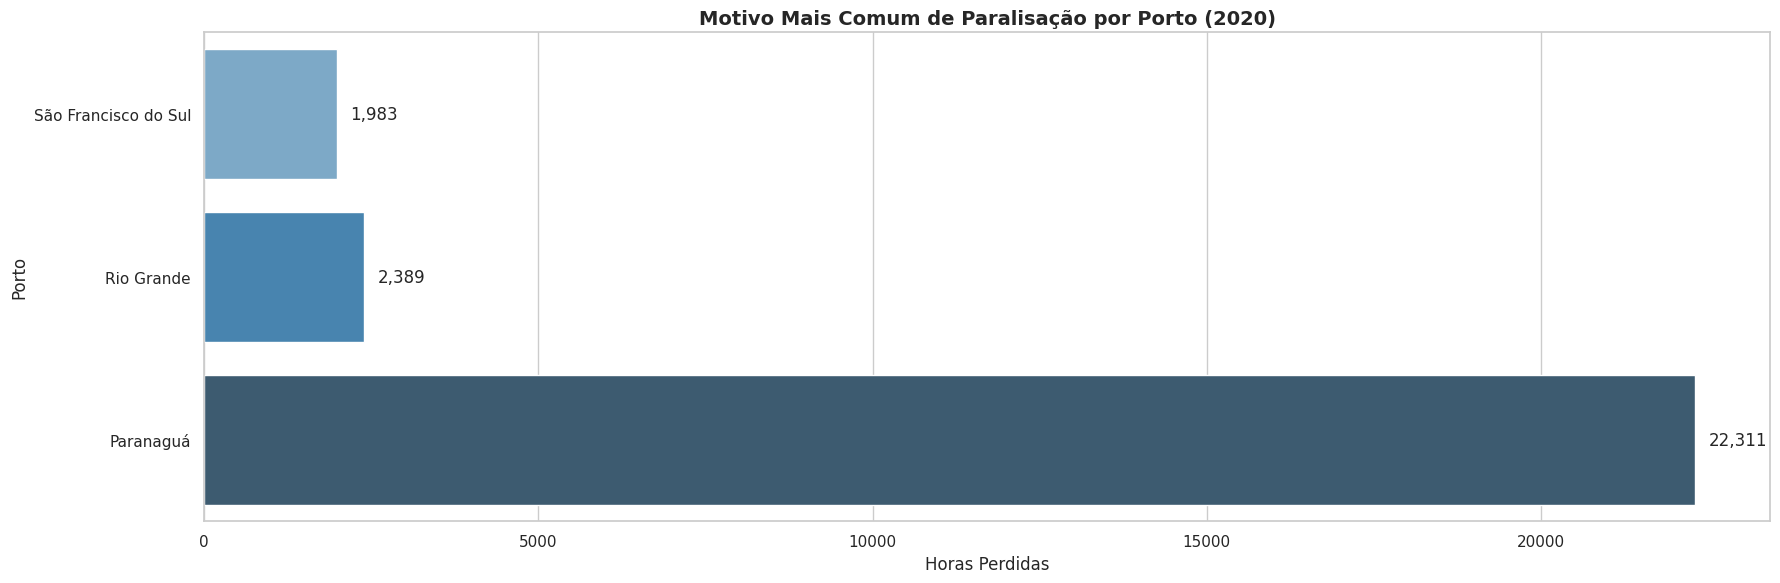

In [92]:
#TIPO MAIS COMUM NO PORTO DE RIO GRANDE(RS), SAO FRANCISCO DO SUL(SC), E PARANAGUA(PR) - HORAS

sns.set(style="whitegrid")
df_portos = df_paralis.merge(df_atrac[['IDAtracacao', 'Porto Atracação']],on='IDAtracacao',how='left')


portos_alvo = ['Paranaguá', 'São Francisco do Sul', 'Rio Grande']
df_filtrado = df_portos[df_portos['Porto Atracação'].isin(portos_alvo)]
agrupado = df_filtrado.groupby(['Porto Atracação', 'DescricaoTempoDesconto'])['Horas Perdidas'].sum().reset_index()

top_motivos = agrupado.sort_values(['Porto Atracação', 'Horas Perdidas'], ascending=[True, False])
top_por_porto = top_motivos.groupby('Porto Atracação').first().reset_index()
top_por_porto_sorted = top_por_porto.sort_values('Horas Perdidas', ascending=True)


plt.figure(figsize=(18, 6))
barplot = sns.barplot(
    data=top_por_porto_sorted,
    x='Horas Perdidas',
    y='Porto Atracação',
    palette='Blues_d'
)
for bar in barplot.patches:
    width = bar.get_width()
    plt.text(width + 200,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}',
             va='center')
plt.title("Motivo Mais Comum de Paralisação por Porto (2020)", fontsize=14, weight='bold')
plt.xlabel("Horas Perdidas")
plt.ylabel("Porto")
plt.tight_layout()
plt.show()

#TODOS OS MOTIVOS FORAM :CHUVA E CONDICOES CLIMATICAS

                  UF  Horas Perdidas
0             Paraná    51839.000000
2     Santa Catarina     7716.433333
1  Rio Grande do Sul     4475.066667
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


/tmp/ipython-input-93-2989629059.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


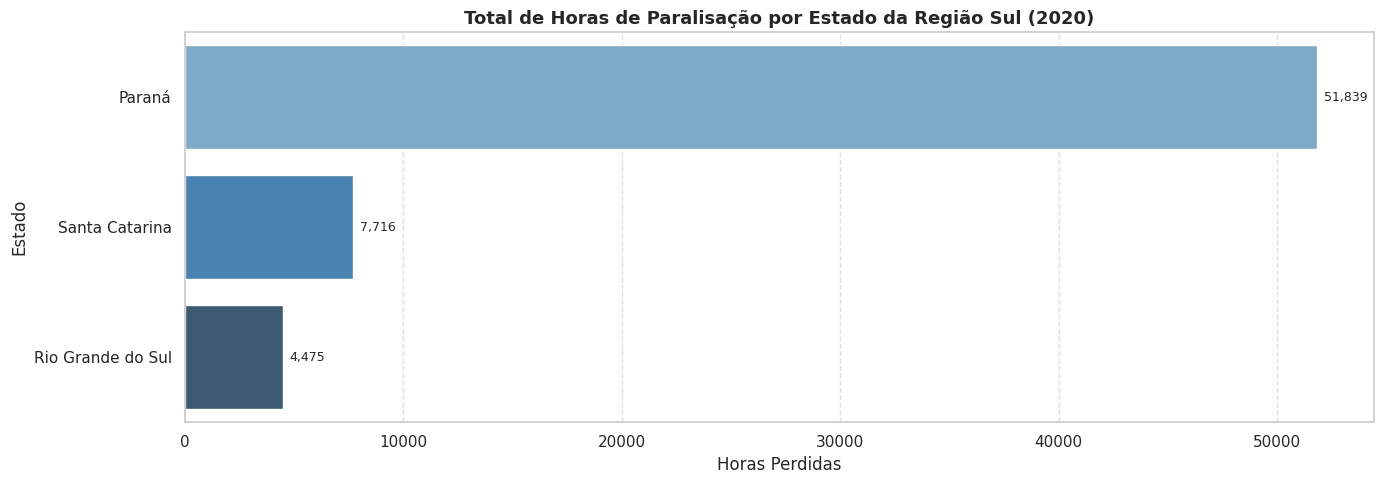

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


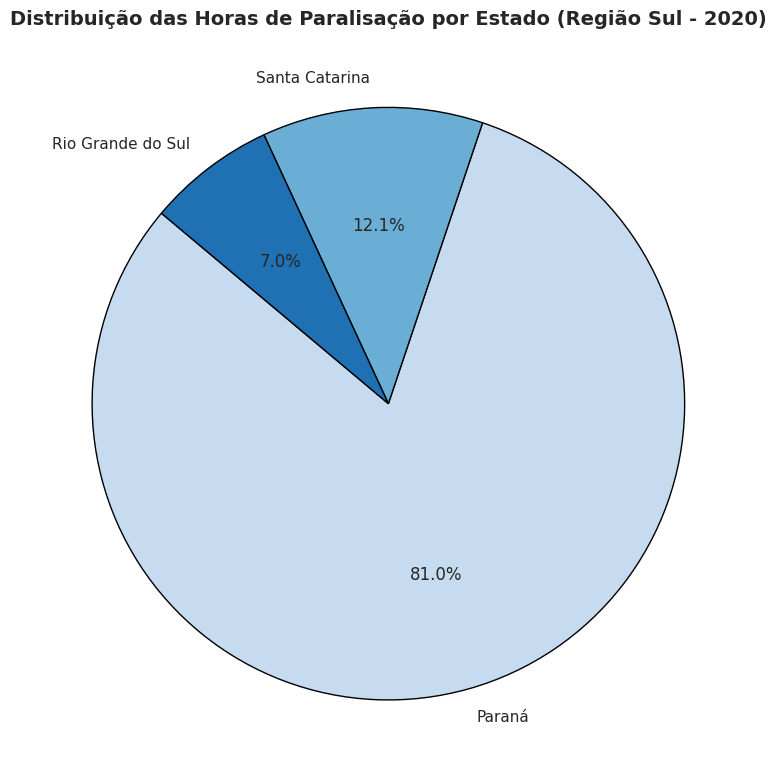

In [93]:
#ESTADO DO SUL QUE MAIS TEM PARALISACAO - HORAS aqui incluiu porto de Antonina

df_paralisado = df_paralis.merge(df_atrac[['IDAtracacao', 'Região Geográfica', 'UF']],on='IDAtracacao', how='left')
df_sul = df_paralisado[df_paralisado['Região Geográfica'] == 'Sul']
paralisacao_por_estado = df_sul.groupby('UF')['Horas Perdidas'].sum().reset_index()
paralisacao_por_estado = paralisacao_por_estado.sort_values(by='Horas Perdidas', ascending=False)

print(paralisacao_por_estado)

print('---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------')

plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data=paralisacao_por_estado,
    x='Horas Perdidas',
    y='UF',
    palette='Blues_d'
)
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 300,
        y,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )

plt.title('Total de Horas de Paralisação por Estado da Região Sul (2020)', fontsize=13, weight='bold')
plt.xlabel('Horas Perdidas')
plt.ylabel('Estado')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------')


labels = paralisacao_por_estado['UF']
sizes = paralisacao_por_estado['Horas Perdidas']
colors = sns.color_palette('Blues', len(labels))
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Distribuição das Horas de Paralisação por Estado (Região Sul - 2020)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


         Porto Atracação  Horas Perdidas
5              Paranaguá    48260.016667
2               Imbituba     3590.633333
0               Antonina     3578.983333
9             Rio Grande     2389.016667
10  São Francisco do Sul     2146.500000
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


/tmp/ipython-input-94-1627837644.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


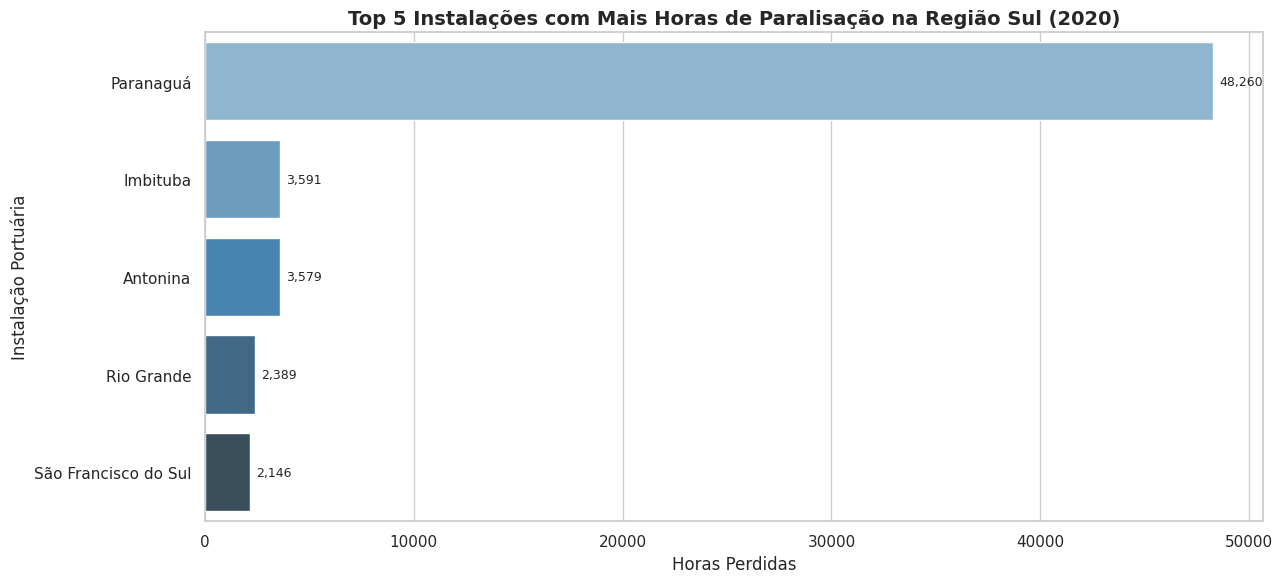

In [94]:
#PORTOS NA REGIÃO SUL COM MAIOR NÚMERO DE HORAS EM PARALISAÇÃO


df_paralisado = df_paralis.merge(df_atrac[['IDAtracacao', 'Região Geográfica', 'Porto Atracação']], on='IDAtracacao',how='left')
df_sul = df_paralisado[df_paralisado['Região Geográfica'] == 'Sul']
top_instalacoes = df_sul.groupby('Porto Atracação')['Horas Perdidas'].sum().reset_index()
top_instalacoes = top_instalacoes.sort_values(by='Horas Perdidas', ascending=False).head(5)
print(top_instalacoes)

print('----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------')


plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=top_instalacoes,
    y='Porto Atracação',
    x='Horas Perdidas',
    palette='Blues_d'
)

for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 300,
        y,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )
plt.title('Top 5 Instalações com Mais Horas de Paralisação na Região Sul (2020)', fontsize=14, weight='bold')
plt.xlabel('Horas Perdidas')
plt.ylabel('Instalação Portuária')
plt.tight_layout()
plt.show()


                                         Porto Atracação                  UF Região Geográfica  Horas Perdidas
                                               Paranaguá              Paraná               Sul    48260.016667
Terminal Aquaviário de São Sebastião (Almirante Barroso)           São Paulo           Sudeste    29421.766667
                           Terminal Aquaviário de Manaus            Amazonas             Norte    11837.100000
                               Base de Caracaraí - BARAC             Roraima             Norte     4435.416667
                                                 Niterói      Rio de Janeiro           Sudeste     4262.866667
                                                Santarém                Pará             Norte     4199.233333
                                            Areia Branca Rio Grande do Norte          Nordeste     3763.583333
                                                Imbituba      Santa Catarina               Sul     3590.633333
 

/tmp/ipython-input-95-3426299374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


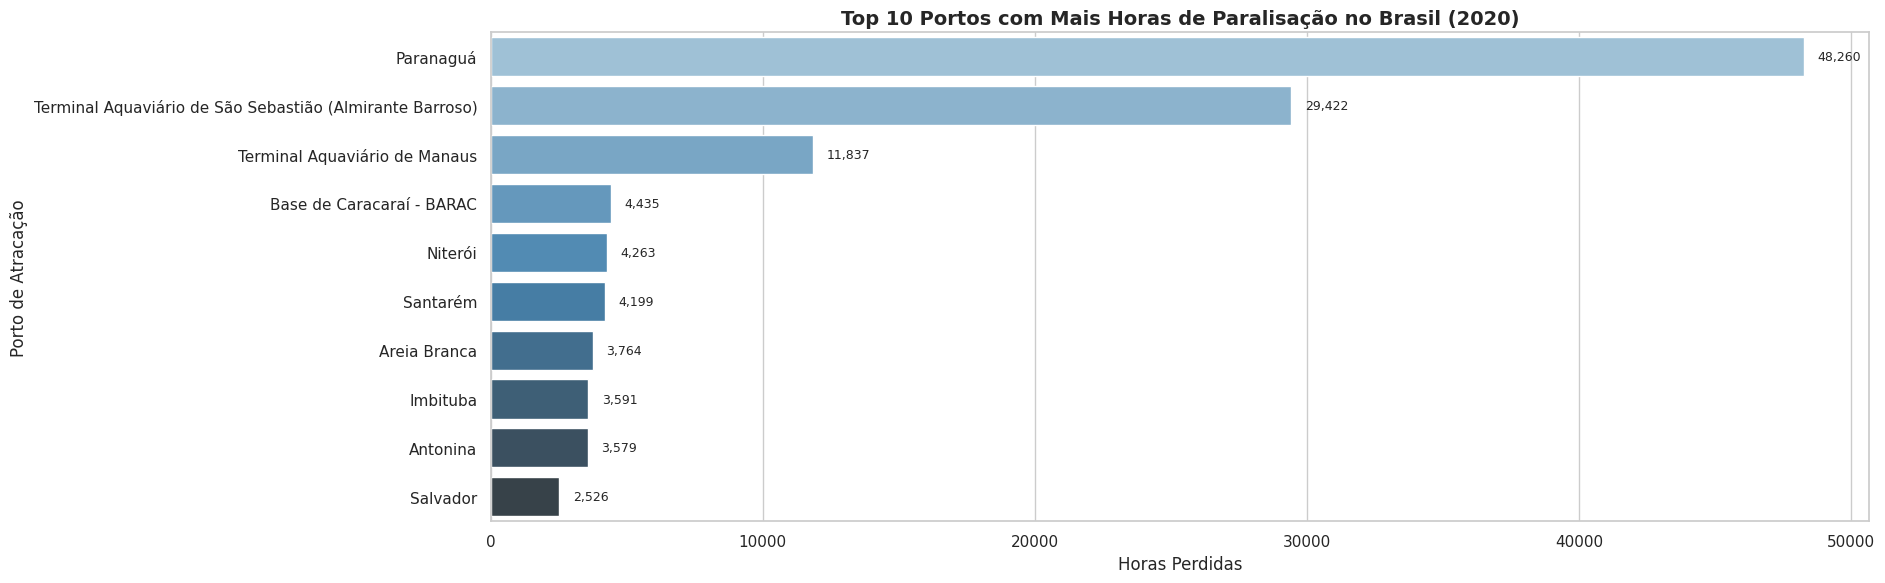

In [95]:
#OS 10 MAIORES  PORTOS EM PARALISACAO POR HORAS EM TODAS AS REGIOES GEOGRAFICAS


df_paralisado = df_paralis.merge(df_atrac[['IDAtracacao', 'Porto Atracação', 'UF', 'Região Geográfica']], on='IDAtracacao',how='left')
top_10_portos = df_paralisado.groupby(['Porto Atracação', 'UF', 'Região Geográfica'])['Horas Perdidas'].sum().reset_index()
top_10_portos = top_10_portos.sort_values(by='Horas Perdidas', ascending=False).head(10)
print(top_10_portos.to_string(index=False))

print('-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------')

plt.figure(figsize=(19, 6))
ax = sns.barplot(
    data=top_10_portos,
    y='Porto Atracação',
    x='Horas Perdidas',
    palette='Blues_d'
)
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    plt.text(
        width + 500,
        y,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )
plt.title('Top 10 Portos com Mais Horas de Paralisação no Brasil (2020)', fontsize=14, weight='bold')
plt.xlabel('Horas Perdidas')
plt.ylabel('Porto de Atracação')
plt.tight_layout()
plt.show()


In [96]:
#CONFERENCIA DE IDS

df_paralis = pd.read_csv('/content/drive/MyDrive/2020/2020TemposAtracacaoParalisacao.txt',sep=';', encoding='utf-8', low_memory=False)
print(df_paralis[['IDAtracacao', 'DescricaoTempoDesconto']].head())
paralisacoes_por_id = df_paralis.groupby('IDAtracacao')['DescricaoTempoDesconto'].nunique().reset_index()
paralisacoes_por_id.columns = ['IDATRACACAO', 'TIPOS_PARALISACAO_UNICOS']

print("\nParalisações únicas por ID:")
print(paralisacoes_por_id.head())

id_exemplo = 1049680
df_id = df_paralis[df_paralis['IDAtracacao'] == id_exemplo]


coluna_tipo = 'TIPOPARALISACAO' if 'TIPOPARALISACAO' in df_id.columns else 'DescricaoTempoDesconto'
tipos = df_id[coluna_tipo].unique()
print(f"\nO ID {id_exemplo} teve {len(tipos)} tipos de paralisação:")
print(tipos)


   IDAtracacao                             DescricaoTempoDesconto
0      1094918  Quebra de equipamento do Operador Portuário, d...
1      1094616  Quebra de equipamento do Operador Portuário, d...
2      1094718                                   Mudança de porão
3      1058960  Chuva e/ou outras condições climáticas desfavo...
4      1058155    Maré para embarcações com restrição de operação

Paralisações únicas por ID:
   IDATRACACAO  TIPOS_PARALISACAO_UNICOS
0      1048861                         1
1      1049680                         3
2      1049791                         1
3      1049799                         1
4      1049800                         1

O ID 1049680 teve 3 tipos de paralisação:
['Chuva e/ou outras condições climáticas desfavoráveis'
 'Maré para embarcações com restrição de operação' 'Arqueação']


In [97]:
#OS 10 ID's MAIS PARALISACOES

frequencia_ids = df_paralis['IDAtracacao'].value_counts().reset_index()
frequencia_ids.columns = ['IDATRACACAO', 'TOTAL_REGISTROS']
print("Os 10 ID's com mais registros:")
print(frequencia_ids.head(10))

frequencia_ids = df_paralis['IDAtracacao'].value_counts().reset_index()
frequencia_ids.columns = ['IDATRACACAO', 'TOTAL_REGISTROS']
top_ids = frequencia_ids.head(10)['IDATRACACAO'].tolist()
print("\nTipos de paralisação  dos 10 IDs com mais registros:\n")
for id_exemplo in top_ids:
    df_id = df_paralis[df_paralis['IDAtracacao'] == id_exemplo]
    coluna_tipo = 'TIPOPARALISACAO' if 'TIPOPARALISACAO' in df_id.columns else 'DescricaoTempoDesconto'
    tipos = df_id[coluna_tipo].unique()
    print(f"ID {id_exemplo} teve {len(tipos)} tipos de paralisação:")
    print(tipos)
    print("-" * 60)

Os 10 ID's com mais registros:
   IDATRACACAO  TOTAL_REGISTROS
0      1063683              214
1      1065572              195
2      1097011              194
3      1104822              182
4      1137695              169
5      1097848              169
6      1130135              166
7      1063737              165
8      1069978              164
9      1110939              163

Tipos de paralisação  dos 10 IDs com mais registros:

ID 1063683 teve 7 tipos de paralisação:
['Maré para embarcações com restrição de operação'
 'Quebra de equipamento do Porto, devidamente comprovada'
 'Limpeza operacional'
 'Quebra de equipamento do Operador Portuário, devidamente comprovada'
 'Chuva e/ou outras condições climáticas desfavoráveis' 'Mudança de porão'
 'Falta de energia elétrica']
------------------------------------------------------------
ID 1065572 teve 8 tipos de paralisação:
['Chuva e/ou outras condições climáticas desfavoráveis'
 'Falta de energia elétrica'
 'Quebra de equipamento do P